In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
fraud = pd.read_csv("creditcard.csv")

In [3]:
fraud.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [4]:
fraud.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## TRAIN TEST AND SPLIT

In [5]:
from sklearn.model_selection import train_test_split


In [6]:
X =fraud.drop("Class",axis = 1)
y = fraud["Class"]

In [8]:
X_train,X_test,y_train,y_test = train_test_split(
        X,y,test_size=0.30)

In [10]:
from sklearn.tree import DecisionTreeClassifier


In [11]:
dtree = DecisionTreeClassifier(criterion = "entropy",random_state = 0)

In [12]:
dtree.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### PREDICTION AND EVALUATION

In [13]:
predictions = dtree.predict(X_test)

In [15]:
predictions

array([0, 0, 0, ..., 0, 0, 0], shape=(85443,))

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85288
           1       0.81      0.75      0.78       155

    accuracy                           1.00     85443
   macro avg       0.91      0.88      0.89     85443
weighted avg       1.00      1.00      1.00     85443



In [19]:
print(confusion_matrix(y_test,predictions))

[[85261    27]
 [   38   117]]


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5904\2499258902.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


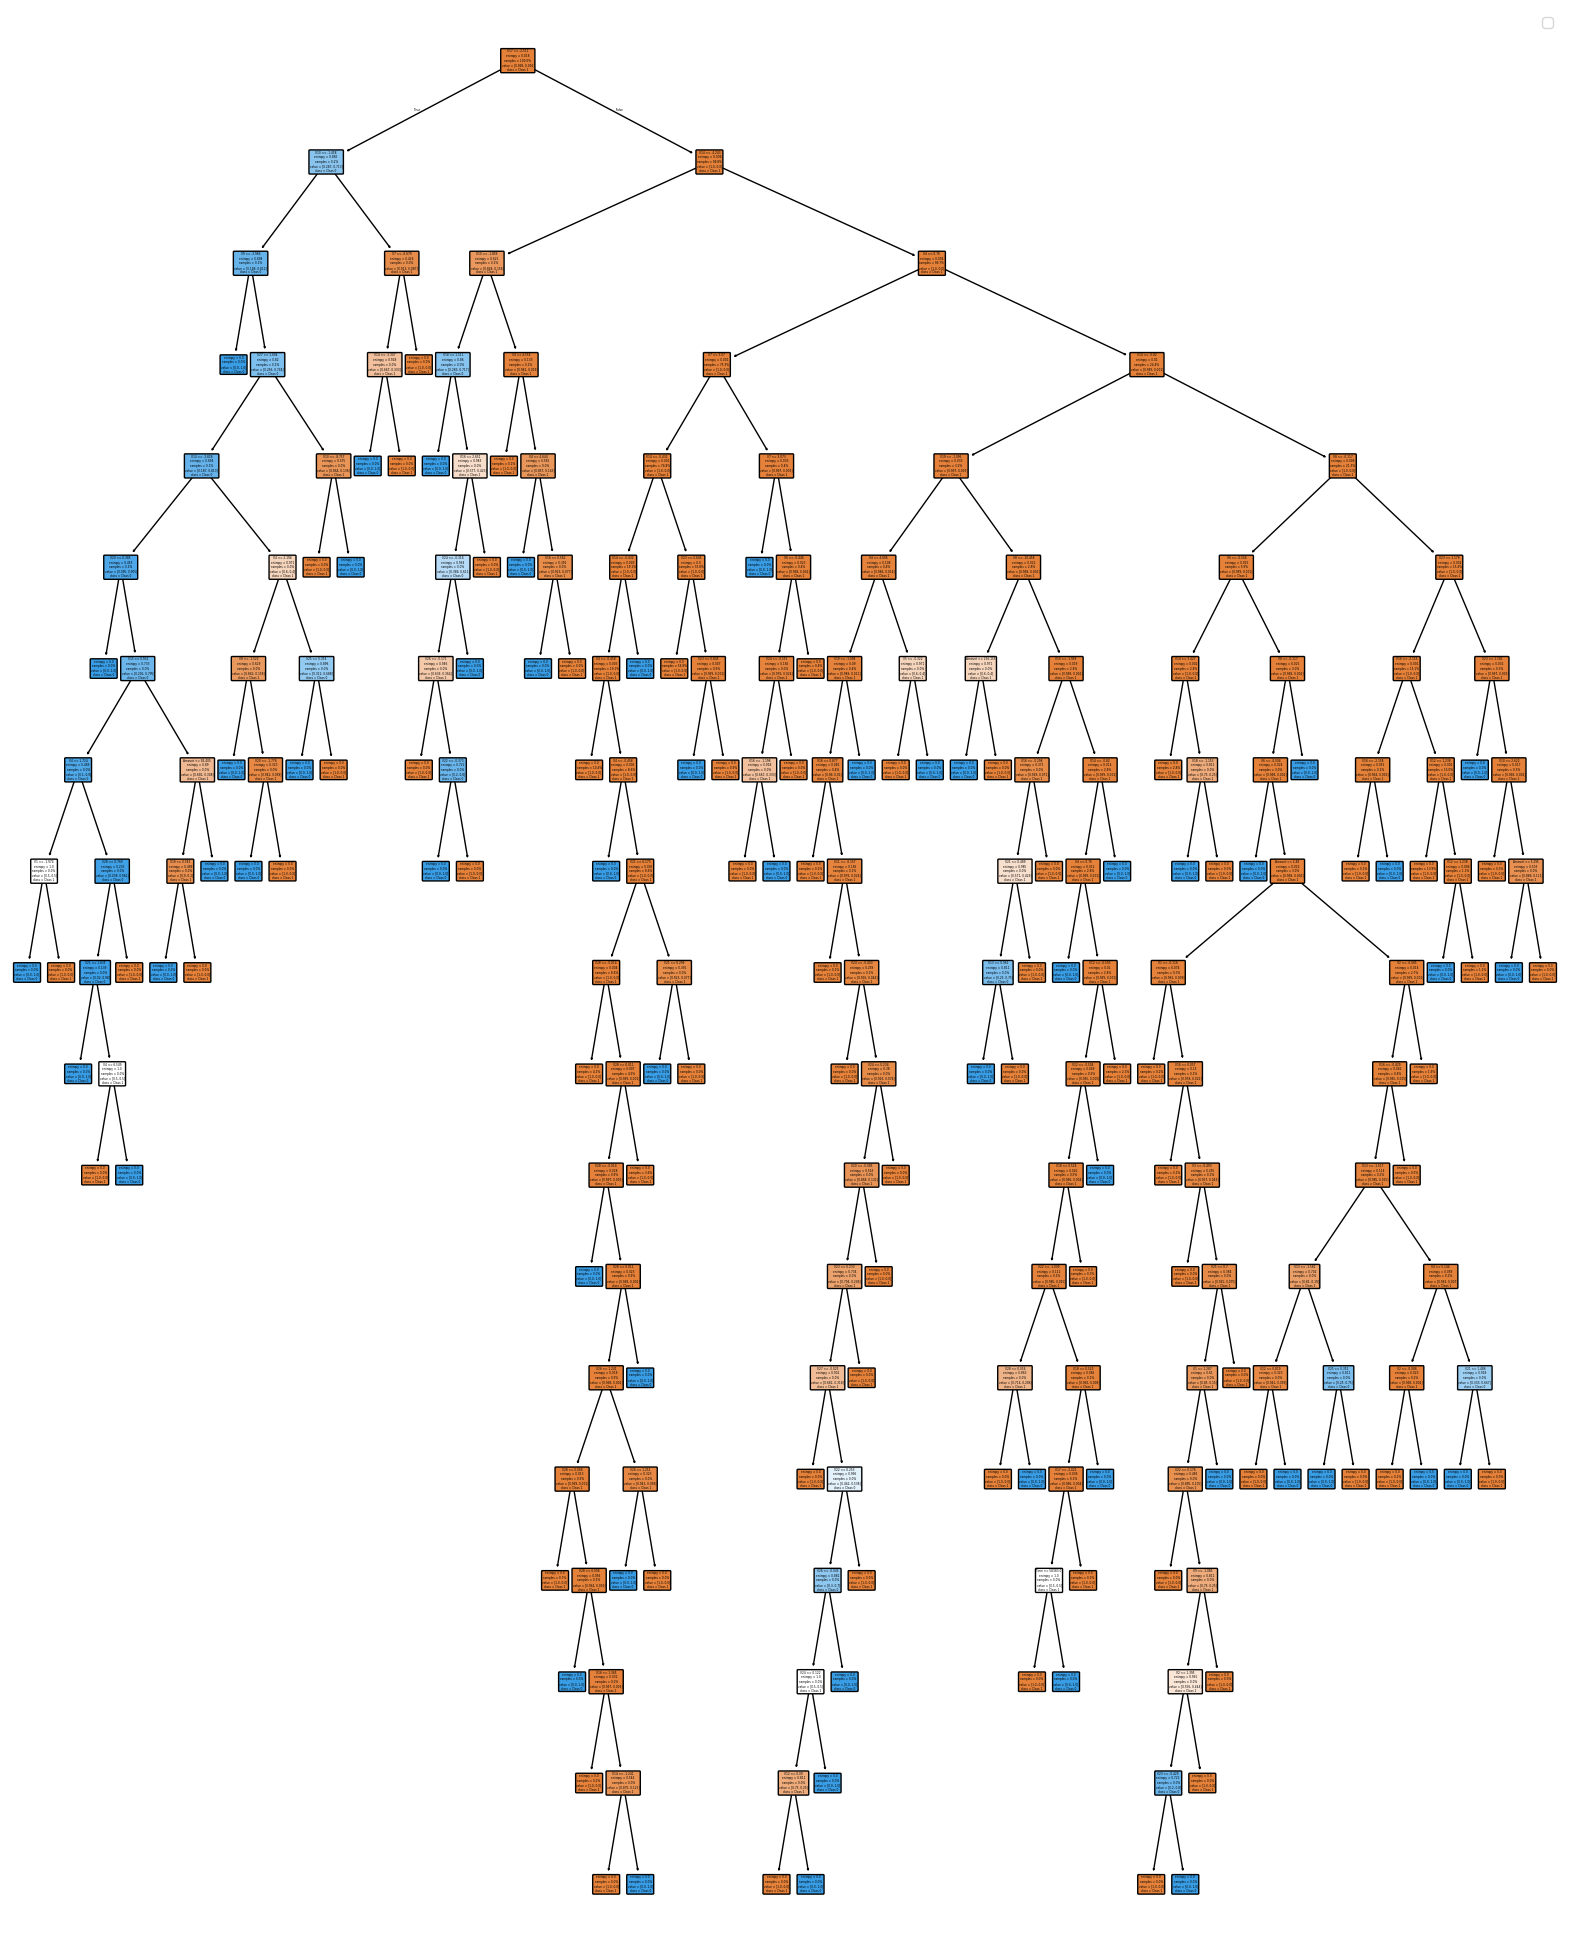

In [23]:
from sklearn import tree

plt.figure(figsize=(20,25))

tree.plot_tree(
    dtree,feature_names = X.columns,
    class_names = ["Class 1","Class 0"],
    rounded=True, #the corners of the box nodes in the diagram
    filled = True,#filled = True: This color-codes the nodes. 
    #Nodes that lean heavily toward one class will be colored deep blue, while nodes leaning toward the other class turn deep orange. 
   
    proportion = True
)
plt.legend()
plt.show()